In [1]:
%matplotlib inline
from pathlib import Path
import sys

PROJECT_ROOT = Path("/data/dn/FRTP_revision1")
IMAGECLS_ROOT = PROJECT_ROOT / "imagecls"
if str(IMAGECLS_ROOT) not in sys.path:
    sys.path.insert(0, str(IMAGECLS_ROOT))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from custom_datasets import _make_loader, make_label_drop_subset, make_recovered_target_replay_subset
from FRPT import get_score, save_recons_fea_to_h5

DEVICE = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")
DATA_ROOT = PROJECT_ROOT / "mydata"
CKPT_ROOT = IMAGECLS_ROOT / "ckpts" / "cifar10"
RECONS_ROOT = IMAGECLS_ROOT / "recons_data"
print("DEVICE:", DEVICE)


DEVICE: cuda:6


In [2]:
"""数据"""
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    transforms.RandomErasing(p=0.25),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

DATASET_NAME = "cifar10"
(CKPT_ROOT / DATASET_NAME).mkdir(parents=True, exist_ok=True)
(RECONS_ROOT / DATASET_NAME).mkdir(parents=True, exist_ok=True)
trainset = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True, transform=transform_train)
testset = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True, transform=transform_test)

BATCH_SIZE = 1024
NUM_WORKERS = 4

train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True) 
test_loader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False) 
print(len(train_loader), len(test_loader))


Files already downloaded and verified
Files already downloaded and verified
49 10


In [9]:
def train_base(model, trainloader, testloader, optimizer, num_epochs, es_patience=5, scheduler=None):
    if scheduler is None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3, threshold=0.0, min_lr=1e-6
        )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    test_acc_ls, loss_ls, train_acc_ls = [], [], []
    best_acc, best_ckpt, wait = -1.0, None, 0

    for epoch in range(num_epochs):
        model.train()
        epoch_loss, sample_num = 0.0, 0

        for x, y in trainloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(model(x)['out'], y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            bs = x.size(0)
            epoch_loss += loss.item() * bs
            sample_num += bs

        epoch_loss /= sample_num
        loss_ls.append(epoch_loss)

        test_acc = get_score(model, testloader, DEVICE)
        test_acc_ls.append(test_acc)
        lr = optimizer.param_groups[0]['lr']

        # train_acc_ls.append(eval_acc(model, trainloader)) # use?

        if len(train_acc_ls):
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}, Train Accuracy: {train_acc_ls[-1]:.4f}, Test Accuracy: {test_acc:.4f}, LR: {lr:.2e}')
        else:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}, Test Accuracy: {test_acc:.4f}, LR: {lr:.2e}')
        
        if ((epoch + 1) % 1 == 0 and (epoch + 1) not in []) or (epoch+1) == num_epochs:
            periodic_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            name = getattr(model, 'name', model.__class__.__name__)
            fname = Path("/data/dn/FRTP_revision1/imagecls/ckpts/everyci10") / f"{name}_e{epoch+71}_{test_acc:.4f}.pth"
            try:
                torch.save(periodic_ckpt, str(fname))
                print(f"Saved periodic checkpoint to {fname}")
            except Exception as e:
                print(f"Failed saving periodic checkpoint: {e}")

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_acc)
            else:
                scheduler.step()
            # if test_acc > best_acc:
            #     best_acc = test_acc
            #     best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            #     wait = 0
            # else:
            #     wait += 1
            #     if es_patience is not None and wait >= es_patience:
            #         print(f'Early stopping at epoch {epoch+1}. Best Test Accuracy: {best_acc:.4f}')
            #         break
    if scheduler is not None:
        model.load_state_dict(best_ckpt)
    return loss_ls, train_acc_ls, test_acc_ls, best_ckpt


In [11]:
"""train baseline model: CIFAR-style ResNet + SGD cosine recipe"""
from models import SimpleCNN_ci10, ResNet_ci10
model = SimpleCNN_ci10(activate=torch.relu, version="v2").to(DEVICE)
model.load_state_dict(torch.load("/data/dn/FRTP_revision1/imagecls/ckpts/everyci10/ci10_simplecnnv2_relu_e70_0.6614.pth", map_location=DEVICE))
optimizer_ = torch.optim.AdamW(model.parameters(), lr=1.25e-4)
EPOCHES = 10
scheduler_ = None

# model = ResNet_ci10(version='18', pretrain=False).to(DEVICE)
# # model.load_state_dict(torch.load("/data/dn/FRTP_revision1/imagecls/ckpts/everyci10/ci10_resnet18_e30_0.8684.pth", map_location=DEVICE))
# EPOCHES = 50
# optimizer_ = torch.optim.SGD( model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4, nesterov=True)
# scheduler_ = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_, T_max=EPOCHES, eta_min=5e-4)

loss_lt, trainacc_lt, testacc_lt, best_ckpt = train_base(model, train_loader, test_loader,
    optimizer_, EPOCHES, scheduler=scheduler_,)
# # print("baseline_loss.extend(")
# print(loss_lt)
# print("baseline_testacc.extend(")
# print(testacc_lt)

/home/dn/.tmp/ipykernel_535778/608237803.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/data/dn/FRTP_revision1/imagecls/ckpts/everyci

Epoch [1/10], Loss: 1.474269, Test Accuracy: 0.6612, LR: 1.25e-04
Saved periodic checkpoint to /data/dn/FRTP_revision1/imagecls/ckpts/everyci10/ci10_simplecnnv2_relu_e71_0.6612.pth
Epoch [2/10], Loss: 1.474436, Test Accuracy: 0.6595, LR: 1.25e-04
Saved periodic checkpoint to /data/dn/FRTP_revision1/imagecls/ckpts/everyci10/ci10_simplecnnv2_relu_e72_0.6595.pth
Epoch [3/10], Loss: 1.475286, Test Accuracy: 0.6646, LR: 1.25e-04
Saved periodic checkpoint to /data/dn/FRTP_revision1/imagecls/ckpts/everyci10/ci10_simplecnnv2_relu_e73_0.6646.pth
Epoch [4/10], Loss: 1.477707, Test Accuracy: 0.6614, LR: 1.25e-04
Saved periodic checkpoint to /data/dn/FRTP_revision1/imagecls/ckpts/everyci10/ci10_simplecnnv2_relu_e74_0.6614.pth
Epoch [5/10], Loss: 1.473754, Test Accuracy: 0.6609, LR: 1.25e-04
Saved periodic checkpoint to /data/dn/FRTP_revision1/imagecls/ckpts/everyci10/ci10_simplecnnv2_relu_e75_0.6609.pth
Epoch [6/10], Loss: 1.470613, Test Accuracy: 0.6605, LR: 1.25e-04
Saved periodic checkpoint to 

TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

## get recons data

In [3]:
from models import SimpleCNN_ci10, ResNet_ci10
# model = ResNet_ci10(version='18', pretrain=False).to(DEVICE)
# MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_resnet18_e5_0.9493.pth"
model = SimpleCNN_ci10(activate=torch.relu, version="v2").to(DEVICE)
# MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_simplecnnv5_relu_e30_0.5813.pth"
# MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_simplecnnv4_relu_e75_0.6102.pth"
MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_simplecnnv2_relu_0.6663.pth"
ckpt = torch.load(MODELPATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt)
model.eval()
test_score = get_score(model, test_loader, DEVICE)
TESTACC = test_score * 100
train_score = get_score(model, train_loader, DEVICE)
TRAINACC = train_score * 100
print(f"testacc={TESTACC:.2f}%, trainacc={TRAINACC:.2f}%")
model.check_cond()

testacc=66.63%, trainacc=50.86%
conv1.weight torch.Size([10, 3, 5, 5]) --------------------
tensor([[5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5]], device='cuda:6')
tensor([[   6.9770,   41.5560,   70.0579],
        [ 527.8046,    8.5403,   17.1785],
        [   8.9913,   15.8482,    8.6037],
        [  75.4604, 2959.6450,   13.8211],
        [ 175.4018,    5.1126,   68.0941],
        [   5.0084,   13.1211,    9.3436],
        [ 695.2333,    9.1623,    9.4473],
        [ 344.5205,    8.1748,   32.5581],
        [  21.4129,   11.2558,   43.6626],
        [  26.3898,   10.4577,   32.8172]], device='cuda:6')
weight matrix rank: tensor(10, device='cuda:6')
weight matrix cond: tensor(2.1745, device='cuda:6', dtype=torch.float64)
conv2.weight torch.Size([10, 10, 3, 3]) --------------------
tensor([[3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
        [3, 3, 3, 3, 3, 3, 3, 

In [4]:
FILEPATH = Path("/data/dn/FRTP_revision1/imagecls/recons_data_new/cifar10") / f"{Path(MODELPATH).stem}.h5"
save_recons_fea_to_h5(model, train_loader, FILEPATH, DEVICE)1

saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/cifar10/ci10_simplecnnv2_relu_0.6663.h5


In [ ]:
from models import SimpleCNN_ci10, ResNet_ci10
import os, re 

for filename in os.listdir("/data/dn/FRTP_revision1/imagecls/ckpts/everyci10"):
    if filename == 'cifar10': continue
    epoch = int(re.search(r"_e(\d+)", filename).group(1))
    if epoch % 2 == 1: continue
    model = SimpleCNN_ci10(activate=torch.relu, version="v2").to(DEVICE)
    # model = ResNet_ci10(version='18', pretrain=False).to(DEVICE)
    MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/everyci10/"+filename
    ckpt = torch.load(MODELPATH, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt)
    model.eval()
    FILEPATH = Path("/data/dn/FRTP_revision1/imagecls/recons_data_new") / 'everyci10' / f"{Path(MODELPATH).stem}.h5"
    if os.path.exists(FILEPATH):
        print("[DONE]", FILEPATH)
        continue
    save_recons_fea_to_h5(model, train_loader, str(FILEPATH), DEVICE)


saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/everyci10/ci10_simplecnnv2_relu_e36_0.5978.h5
saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/everyci10/ci10_simplecnnv2_relu_e18_0.5959.h5
saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/everyci10/ci10_simplecnnv2_relu_e58_0.6590.h5
saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/everyci10/ci10_simplecnnv2_relu_e12_0.5715.h5
saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/everyci10/ci10_simplecnnv2_relu_e76_0.6605.h5
saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/everyci10/ci10_simplecnnv2_relu_e70_0.6614.h5
saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/everyci10/ci10_simplecnnv2_relu_e24_0.6058.h5
saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/everyci10/ci10_simplecnnv2_relu_e20_0.5984.h5
saved recons data to /data/dn/FRTP_revision1/imagecls/recons_data_new/ev

: 

## FRPT

In [ ]:
from models import SimpleCNN_ci10, ResNet_ci10
# model = SimpleCNN_ci10(activate=torch.relu, version='v2').to(DEVICE)
# MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_simplecnnv2_relu_0.6738.pth"
model = ResNet_ci10(version='18', pretrain=False).to(DEVICE)
MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_resnet18_epoch90_0.8793.pth"
EPOCHS=10
SEED_ls = [0,1,2,3,4,5,6,7,8,9][:1]
ALPHA_ls = [0,0.1]

summary_res = model_post_train_all(model, MODELPATH, test_loader, 
                ALPHA_ls, SEED_ls, EPOCHS, DEVICE, BATCH_SIZE, save_res=False)

## ablation


In [ ]:
from models import SimpleCNN_ci10
model = SimpleCNN_ci10(activate=torch.relu, version="v1").to(DEVICE)
MODELPATH =  "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_simplecnnv1_relu_0.6615.pth"
EPOCHS = 10
ALPHA_ls = [0, 0.1, 0.3, 0.5, 0.7, 0.9]
SEED_ls = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9][:1]

ablation_summary = ablation_all(
    model, MODELPATH, test_loader, ALPHA_ls, SEED_ls, EPOCHS, DEVICE, BATCH_SIZE, save_res=False)

## visualize


image: torch.Size([3, 32, 32])
forward feature: torch.Size([10, 28, 28])
reconstructed feature: torch.Size([10, 28, 28])
label: 9 pred: 9


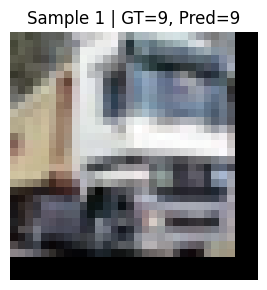

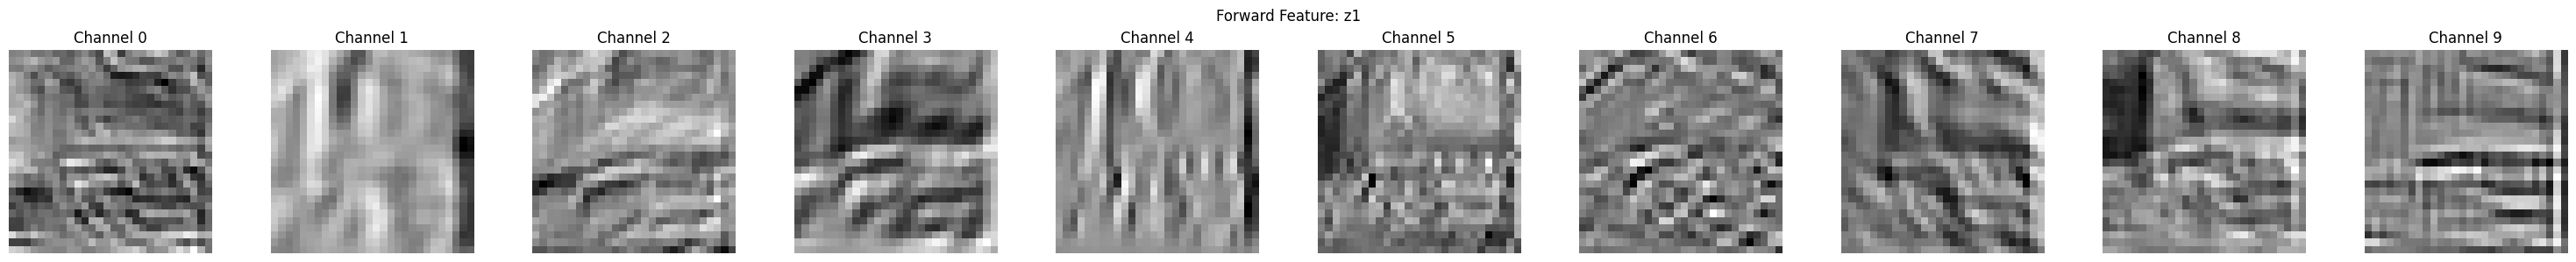

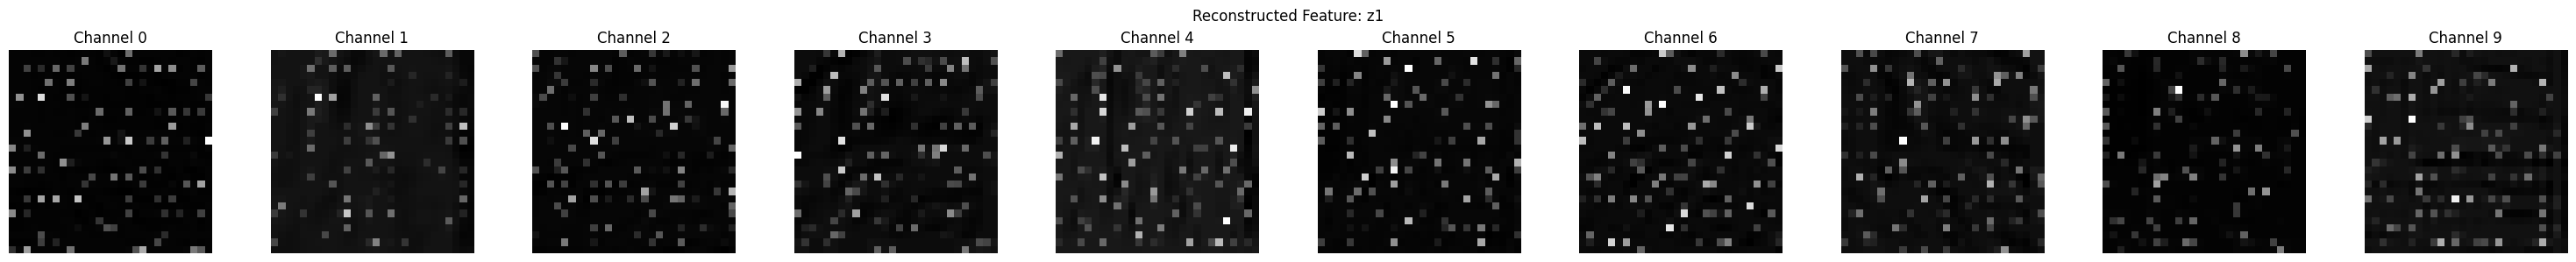

In [20]:
import torch
import matplotlib.pyplot as plt
from models import SimpleCNN_ci10

MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_simplecnnv2_relu_0.6620.pth"
SAMPLE_IDX = 1
LAYER_NAME = "z1"     # z1, z2, z3

model = SimpleCNN_ci10(activate=torch.relu,version="v2").to(DEVICE)
model.load_state_dict( torch.load(MODELPATH, map_location=DEVICE, weights_only=True))
model.eval()
image, label = trainset[SAMPLE_IDX]
image = image.unsqueeze(0).to(DEVICE)   # [1, 3, H, W]
label = torch.tensor([label], dtype=torch.long, device=DEVICE)

with torch.no_grad():
    res = model(image)
    pred = res["out"].argmax(dim=1).item()
    forward_fea = res[LAYER_NAME][0]    # [C, H, W]
    recons_fea = model.get_recons_fea(
        input_data=image, label_data=label, recons_key=f"recons_{LAYER_NAME}",)

image = image[0]                         # [3, H, W]
if recons_fea.ndim == 4:
    recons_fea = recons_fea[0]          # [C, H, W]

print("image:", image.shape)
print("forward feature:", forward_fea.shape)
print("reconstructed feature:", recons_fea.shape)
print("label:", label.item(), "pred:", pred)

def denormalize_cifar10(x):
    CIFAR10_MEAN = torch.tensor(
        [0.4914, 0.4822, 0.4465],
        dtype=image.dtype,
        device=image.device,
    ).view(3, 1, 1)

    CIFAR10_STD = torch.tensor(
        [0.2470, 0.2435, 0.2616],
        dtype=image.dtype,
        device=image.device,
    ).view(3, 1, 1)

    return (x * CIFAR10_STD + CIFAR10_MEAN).clamp(0, 1)

img = denormalize_cifar10(image)
img = img.detach().cpu().permute(1, 2, 0).numpy()   # CHW -> HWC
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f"Sample {SAMPLE_IDX} | GT={label.item()}, Pred={pred}")
plt.axis("off")
plt.tight_layout()
plt.show()

forward_fea_cpu = forward_fea.detach().cpu()
C = forward_fea_cpu.shape[0]
fig, axes = plt.subplots(1, C, figsize=(3 * C, 3),squeeze=False)
axes = axes[0]
for c in range(C):
    axes[c].imshow(forward_fea_cpu[c], cmap="gray")
    axes[c].set_title(f"Channel {c}")
    axes[c].axis("off")
fig.suptitle(f"Forward Feature: {LAYER_NAME}")
plt.tight_layout()
plt.show()

recons_fea_cpu = recons_fea.detach().cpu()
C = recons_fea_cpu.shape[0]
fig, axes = plt.subplots(1, C, figsize=(3 * C, 3), squeeze=False)
axes = axes[0]
for c in range(C):
    axes[c].imshow(recons_fea_cpu[c], cmap="gray")
    axes[c].set_title(f"Channel {c}")
    axes[c].axis("off")

fig.suptitle(f"Reconstructed Feature: {LAYER_NAME}")
plt.tight_layout()
plt.show()

In [3]:
from pathlib import Path
from torch.utils.data import Subset
from models import SimpleCNN_ci10
from FRPT import get_score, save_recons_fea_to_h5

CIFAR10_CLASSES = trainset.classes if hasattr(trainset, "classes") else [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
OOD_TARGET_CLASS = "cat"
OOD_TARGET_LABEL = CIFAR10_CLASSES.index(OOD_TARGET_CLASS)
OOD_DROP_RATIO = 0.90
OOD_SEED = 42
OOD_VERSION = "v2"
OOD_BATCH_SIZE = BATCH_SIZE
OOD_EPOCHS = 50
OOD_NUM_WORKERS = 2

OOD_CKPT_DIR = Path("/data/dn/FRTP_revision1/imagecls/ckpts/cifar10")
OOD_RECONS_DIR = Path("/data/dn/FRTP_revision1/imagecls/recons_data/cifar10")
OOD_CKPT_DIR.mkdir(parents=True, exist_ok=True)
OOD_RECONS_DIR.mkdir(parents=True, exist_ok=True)


def make_label_drop_subset(dataset, target_label, drop_ratio=0.9, seed=42):
    targets = torch.as_tensor(dataset.targets)
    target_idx = torch.where(targets == target_label)[0]
    other_idx = torch.where(targets != target_label)[0]

    keep_num = max(1, int(round(target_idx.numel() * (1.0 - drop_ratio))))
    g = torch.Generator().manual_seed(seed)
    kept_target_idx = target_idx[torch.randperm(target_idx.numel(), generator=g)[:keep_num]]

    keep_idx = torch.cat([other_idx, kept_target_idx])
    keep_idx = keep_idx[torch.randperm(keep_idx.numel(), generator=g)]
    return Subset(dataset, keep_idx.tolist()), keep_num, target_idx.numel()


def train_base_ood(model, trainloader, testloader, optimizer, num_epochs, es_patience=5, scheduler=None):
    if scheduler is None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=3, threshold=0.0, min_lr=1e-6
        )

    criterion = nn.CrossEntropyLoss()
    test_acc_ls, loss_ls, train_acc_ls = [], [], []
    best_acc, best_ckpt, wait = -1.0, None, 0

    for epoch in range(num_epochs):
        model.train()
        epoch_loss, sample_num = 0.0, 0

        for x, y in trainloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(model(x)["out"], y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = x.size(0)
            epoch_loss += loss.item() * bs
            sample_num += bs

        epoch_loss /= sample_num
        test_acc = get_score(model, testloader, DEVICE)
        scheduler.step(test_acc)

        loss_ls.append(epoch_loss)
        test_acc_ls.append(test_acc)
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch [{epoch+1}/{num_epochs}], loss={epoch_loss:.4f}, testacc={test_acc:.4f}, lr={lr:.6g}")

        if test_acc > best_acc:
            best_acc = test_acc
            best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= es_patience:
                print(f"Early stop at epoch {epoch+1}; best testacc={best_acc:.4f}")
                break

    return loss_ls, train_acc_ls, test_acc_ls, best_ckpt


trainset_ood, kept_cat_num, total_cat_num = make_label_drop_subset(
    trainset, OOD_TARGET_LABEL, OOD_DROP_RATIO, OOD_SEED
)
print(
    f"train subset size={len(trainset_ood)}; "
    f"kept {kept_cat_num}/{total_cat_num} {OOD_TARGET_CLASS} samples "
    f"after dropping {OOD_DROP_RATIO:.0%}"
)

g = torch.Generator().manual_seed(OOD_SEED)
train_loader_ood = DataLoader(
    trainset_ood,
    batch_size=OOD_BATCH_SIZE,
    shuffle=True,
    num_workers=OOD_NUM_WORKERS,
    generator=g,
)
test_loader_ood = DataLoader(
    testset,
    batch_size=OOD_BATCH_SIZE,
    shuffle=False,
    num_workers=OOD_NUM_WORKERS,
)

model_ood = SimpleCNN_ci10(activate=torch.relu, version=OOD_VERSION).to(DEVICE)
optimizer_ood = torch.optim.AdamW(model_ood.parameters(), lr=0.001)
ood_loss_lt, ood_trainacc_lt, ood_testacc_lt, ood_best_ckpt = train_base_ood(
    model_ood,
    train_loader_ood,
    test_loader_ood,
    optimizer_ood,
    OOD_EPOCHS,
)

model_ood.load_state_dict(ood_best_ckpt)
OOD_MODELPATH = OOD_CKPT_DIR / (
    f"{model_ood.name}_drop{int(OOD_DROP_RATIO * 100)}pct_"
    f"{OOD_TARGET_CLASS}_{max(ood_testacc_lt):.4f}.pth"
)
torch.save(ood_best_ckpt, OOD_MODELPATH)
print(f"saved OOD model to {OOD_MODELPATH}")

OOD_FILEPATH = OOD_RECONS_DIR / f"{OOD_MODELPATH.stem}.h5"
save_recons_fea_to_h5(model_ood, train_loader_ood, str(OOD_FILEPATH), DEVICE)


In [4]:
from pathlib import Path
from matplotlib import colors
from models import SimpleCNN_ci10
CIFAR10_MEAN = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
CIFAR10_STD = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)
OOD_FEATURE_NAME = "z1"
OOD_MAX_CHANNELS = 6
OOD_CONV_METHOD = "fft_pad"
OOD_DIFF_PERCENTILE = 0.90
OOD_DIFF_LEVELS = 7
CIFAR10_CLASSES = trainset.classes if hasattr(trainset, "classes") else [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
OOD_TARGET_CLASS = "cat"
OOD_TARGET_LABEL = CIFAR10_CLASSES.index(OOD_TARGET_CLASS)
OOD_DROP_RATIO = 0.90
OOD_SEED = 42
OOD_VERSION = "v2"
OOD_BATCH_SIZE = BATCH_SIZE
OOD_EPOCHS = 50
OOD_NUM_WORKERS = 2
OOD_SAMPLE_ID = 0  # 指定 testset 样本 id；设为 None 时自动找错分样本
OOD_CKPT_DIR = Path("/data/dn/FRTP_revision1/imagecls/ckpts/cifar10")
OOD_RECONS_DIR = Path("/data/dn/FRTP_revision1/imagecls/recons_data/cifar10")
OOD_CKPT_DIR.mkdir(parents=True, exist_ok=True)
OOD_RECONS_DIR.mkdir(parents=True, exist_ok=True)

def load_ood_model_if_needed():
    global model_ood, OOD_MODELPATH
    try:
        model_ood
        OOD_MODELPATH
    except NameError:
        model_ood = SimpleCNN_ci10(activate=torch.relu, version='v2').to(DEVICE)
        OOD_MODELPATH = "/data/dn/FRTP_revision1/imagecls/ckpts/cifar10/ci10_simplecnnv2_relu_0.6663.pth"
        model_ood.load_state_dict(torch.load(OOD_MODELPATH, map_location=DEVICE, weights_only=True))
        print(f"loaded OOD model from {OOD_MODELPATH}")
    model_ood.eval()
    return model_ood


def denormalize_cifar10(x):
    img = x.detach().cpu() * CIFAR10_STD + CIFAR10_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


_MISCLASSIFIED_SAMPLE_STATE = {}


def reset_misclassified_sample_state():
    _MISCLASSIFIED_SAMPLE_STATE.clear()


def _misclassified_state_key(model, dataset, target_label, unique_error_type):
    return (id(model), id(dataset), int(target_label), bool(unique_error_type))


def find_misclassified_sample(
    model,
    dataset,
    target_label=None,
    device=DEVICE,
    batch_size=OOD_BATCH_SIZE,
    unique_error_type=False,
    reset=False,
):
    """
    Deterministically scan dataset with shuffle=False and return the next unseen
    misclassified sample. If unique_error_type=True, each (true_label, pred_label)
    pair is returned at most once.
    """
    key = _misclassified_state_key(model, dataset, -1 if target_label is None else target_label, unique_error_type)
    if reset or key not in _MISCLASSIFIED_SAMPLE_STATE:
        _MISCLASSIFIED_SAMPLE_STATE[key] = {"next_index": 0, "seen_indices": set(), "seen_error_types": set()}
    state = _MISCLASSIFIED_SAMPLE_STATE[key]

    n = len(dataset)
    start = int(state["next_index"]) % n
    scan_order = list(range(start, n)) + list(range(0, start))
    model.eval()

    with torch.no_grad():
        for sample_index in scan_order:
            x, y = dataset[sample_index]
            if not torch.is_tensor(y):
                y = torch.tensor(y, dtype=torch.long)
            x = x.unsqueeze(0).to(device)
            y = y.view(1).to(device)

            logits = model(x)["out"]
            pred = logits.argmax(dim=1)
            is_wrong = bool((pred != y).item())
            label_ok = target_label is None or int(y.item()) == int(target_label)
            if not (is_wrong and label_ok):
                continue
            if sample_index in state["seen_indices"]:
                continue

            error_type = (int(y.item()), int(pred.item()))
            if unique_error_type and error_type in state["seen_error_types"]:
                continue

            state["seen_indices"].add(sample_index)
            state["seen_error_types"].add(error_type)
            state["next_index"] = (sample_index + 1) % n
            return x, error_type[0], error_type[1], logits[0].detach(), sample_index

    reset_note = " Try reset_misclassified_sample_state() to scan again."
    if target_label is None:
        raise RuntimeError("No unseen misclassified sample found." + reset_note)
    raise RuntimeError(f"No unseen misclassified {CIFAR10_CLASSES[target_label]} sample found." + reset_note)


def normalize_map(arr, eps=1e-12):
    arr = np.asarray(arr, dtype=np.float32)
    arr_min, arr_max = float(arr.min()), float(arr.max())
    return (arr - arr_min) / (arr_max - arr_min + eps)


def show_vector_compare(forward_feature, recons_feature, feature_name, label_name, pred_name, sample_index):
    f = forward_feature.detach().cpu().float().flatten().numpy()
    r = recons_feature.detach().cpu().float().flatten().numpy()
    d = r - f

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].plot(f)
    axes[0].set_title(f"forward {feature_name}")
    axes[1].plot(r)
    axes[1].set_title(f"recons {feature_name}")
    axes[2].plot(d)
    axes[2].set_title("recons - forward")
    for ax in axes:
        ax.grid(alpha=0.25)
    fig.suptitle(f"sample={sample_index}, true={label_name}, pred={pred_name}", y=1.05)
    plt.tight_layout()
    plt.show()


def get_sample_case_by_id(model, dataset, sample_id, device=DEVICE):
    x, y = dataset[int(sample_id)]
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.long)
    input_data = x.unsqueeze(0).to(device)
    label = int(y.item())
    model.eval()
    with torch.no_grad():
        logits = model(input_data)["out"][0].detach()
        pred = int(logits.argmax().item())
    return input_data, label, pred, logits, int(sample_id)


def visualize_forward_with_recons_diff(model, dataset, target_label=None, feature_name=OOD_FEATURE_NAME, sample_id=None, unique_error_type=False, reset=False):
    if sample_id is None:
        input_data, label, pred, logits, sample_index = find_misclassified_sample(
            model, dataset, target_label, unique_error_type=unique_error_type, reset=reset
        )
    else:
        input_data, label, pred, logits, sample_index = get_sample_case_by_id(model, dataset, sample_id)
    label_name, pred_name = CIFAR10_CLASSES[label], CIFAR10_CLASSES[pred]
    label_tensor = torch.tensor([label], device=input_data.device)

    model.eval()
    with torch.no_grad():
        forward_res = model(input_data)
        recons_res = model.get_recons_fea(input_data, label_tensor, conv_method=OOD_CONV_METHOD)

    forward_feature = forward_res[feature_name][0]
    recons_feature = recons_res[f"recons_{feature_name}"][0]
    print(
        f"sample={sample_index}, true={label_name}, pred={pred_name}, "
        f"forward[{feature_name}]={tuple(forward_feature.shape)}, "
        f"recons[{feature_name}]={tuple(recons_feature.shape)}"
    )

    if forward_feature.ndim < 3:
        show_vector_compare(forward_feature, recons_feature, feature_name, label_name, pred_name, sample_index)
        return

    channel_count = min(forward_feature.shape[0], OOD_MAX_CHANNELS)
    fig, axes = plt.subplots(3, channel_count + 1, figsize=(2.8 * (channel_count + 1), 8.0))

    axes[0, 0].imshow(denormalize_cifar10(input_data[0]))
    axes[0, 0].set_title(f"input\ntrue={label_name}, pred={pred_name}")
    axes[1, 0].axis("off")
    axes[2, 0].axis("off")

    diff_abs = (recons_feature - forward_feature).detach().cpu().abs().numpy()
    vmax = np.quantile(diff_abs, OOD_DIFF_PERCENTILE)
    vmax = max(float(vmax), 1e-8)
    bounds = np.linspace(-vmax, vmax, OOD_DIFF_LEVELS)
    norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256, clip=True)

    for ch in range(channel_count):
        f_map = forward_feature[ch].detach().cpu().numpy()
        r_map = recons_feature[ch].detach().cpu().numpy()
        d_map = r_map - f_map

        axes[0, ch + 1].imshow(normalize_map(f_map), cmap="gray")
        axes[0, ch + 1].set_title(f"forward {feature_name}[{ch}]")

        axes[1, ch + 1].imshow(normalize_map(r_map), cmap="gray")
        axes[1, ch + 1].set_title(f"recons {feature_name}[{ch}]")

        axes[2, ch + 1].imshow(normalize_map(f_map), cmap="gray")
        diff_im = axes[2, ch + 1].imshow(d_map, cmap="bwr", norm=norm, alpha=0.65)
        axes[2, ch + 1].set_title("diff overlay")

    for ax in axes.ravel():
        ax.axis("off")
    fig.colorbar(diff_im, ax=axes[2, 1:].ravel().tolist(), fraction=0.025, pad=0.02, label="recons - forward")
    print(f"sample_index={sample_index}, true={label} ({label_name}), pred={pred} ({pred_name})")
    print(f"logits={logits.detach().cpu().numpy().round(3).tolist()}")
    plt.tight_layout()
    plt.show()


model_ood = load_ood_model_if_needed()
visualize_forward_with_recons_diff(model_ood, testset, OOD_TARGET_LABEL, OOD_FEATURE_NAME, sample_id=OOD_SAMPLE_ID, unique_error_type=False)




In [11]:
import torch.nn.functional as F

CAM_DIFF_FEATURE_NAME = "z3"
CAM_RECONS_FEATURE_NAME = "z3"
CAM_FORWARD_FEATURE_NAME = "z3"
CAM_ALPHA = 0.4
CAM_CMAP = "jet"
CAM_SAMPLE_ID = None  # 指定 testset 样本 id；设为 None 时自动找错分样本

def upsample_cam(cam, size=(32, 32)):
    cam = torch.as_tensor(cam, dtype=torch.float32).view(1, 1, *cam.shape)
    cam = F.interpolate(cam, size=size, mode="bilinear", align_corners=False)[0, 0].numpy()
    return normalize_map(cam)


def feature_map_to_cam(feature):
    feature = feature.detach().cpu().float()
    if feature.ndim == 3:
        cam = feature.abs().mean(dim=0).numpy()
    elif feature.ndim == 2:
        cam = feature.abs().numpy()
    else:
        cam = np.full((32, 32), float(feature.abs().mean()))
    return upsample_cam(cam, size=(32, 32)) if cam.shape != (32, 32) else normalize_map(cam)


def get_diff_driven_cam(model, input_data, label, feature_name=CAM_DIFF_FEATURE_NAME):
    label_tensor = torch.tensor([label], device=input_data.device)
    with torch.no_grad():
        forward_res = model(input_data)
        recons_res = model.get_recons_fea(input_data, label_tensor, conv_method=OOD_CONV_METHOD)
    forward_feature = forward_res[feature_name][0]
    recons_feature = recons_res[f"recons_{feature_name}"][0]
    return feature_map_to_cam(recons_feature - forward_feature)


def get_recons_feature_cam(model, input_data, label, feature_name=CAM_RECONS_FEATURE_NAME):
    label_tensor = torch.tensor([label], device=input_data.device)
    with torch.no_grad():
        recons_feature = model.get_recons_fea(
            input_data, label_tensor, conv_method=OOD_CONV_METHOD
        )[f"recons_{feature_name}"][0]
    return feature_map_to_cam(recons_feature)


def get_forward_feature_cam(model, input_data, feature_name=CAM_FORWARD_FEATURE_NAME):
    with torch.no_grad():
        forward_feature = model(input_data)[feature_name][0]
    return feature_map_to_cam(forward_feature)


def show_cam_overlay(ax, rgb_img, cam, title):
    ax.imshow(rgb_img)
    im = ax.imshow(cam, cmap=CAM_CMAP, alpha=CAM_ALPHA, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    return im


def get_sample_case_by_id(model, dataset, sample_id, device=DEVICE):
    x, y = dataset[int(sample_id)]
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.long)
    input_data = x.unsqueeze(0).to(device)
    label = int(y.item())
    model.eval()
    with torch.no_grad():
        logits = model(input_data)["out"][0].detach()
        pred = int(logits.argmax().item())
    return input_data, label, pred, logits, int(sample_id)


def visualize_input_cam_compare(model, dataset, target_label=None, sample_id=None, unique_error_type=False, reset=False):
    if sample_id is None:
        input_data, label, pred, logits, sample_index = find_misclassified_sample(
            model, dataset, target_label, unique_error_type=unique_error_type, reset=reset
        )
    else:
        input_data, label, pred, logits, sample_index = get_sample_case_by_id(model, dataset, sample_id)
    label_name, pred_name = CIFAR10_CLASSES[label], CIFAR10_CLASSES[pred]
    rgb_img = denormalize_cifar10(input_data[0])

    diff_cam = get_diff_driven_cam(model, input_data, label, CAM_DIFF_FEATURE_NAME)
    recons_cam = get_recons_feature_cam(model, input_data, label, CAM_RECONS_FEATURE_NAME)
    forward_cam = get_forward_feature_cam(model, input_data, CAM_FORWARD_FEATURE_NAME)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"input\ntrue={label_name}, pred={pred_name}")
    axes[0].axis("off")
    im1 = show_cam_overlay(axes[1], rgb_img, forward_cam, f"forward {CAM_FORWARD_FEATURE_NAME}")
    im2 = show_cam_overlay(axes[2], rgb_img, recons_cam, f"recons {CAM_RECONS_FEATURE_NAME}")
    im3 = show_cam_overlay(axes[3], rgb_img, diff_cam, f"diff {CAM_DIFF_FEATURE_NAME}")
    fig.colorbar(im3, ax=axes[1:].ravel().tolist(), fraction=0.025, pad=0.02, label="normalized CAM")
    fig.suptitle(f"sample index={sample_index}, true={label_name}, pred={pred_name}", y=1.03)
    plt.tight_layout()
    plt.show()

    print(f"sample_index={sample_index}, true={label} ({label_name}), pred={pred} ({pred_name})")
    print(f"logits={logits.detach().cpu().numpy().round(3).tolist()}")

OOD_TARGET_LABEL=5
model_ood = load_ood_model_if_needed()
visualize_input_cam_compare(model_ood, testset, OOD_TARGET_LABEL, sample_id=CAM_SAMPLE_ID, unique_error_type=False)


## different stage vs recons loss

In [ ]:
from models import SimpleCNN_ci10, ResNet_ci10
train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)
print(len(train_loader), len(test_loader))
